In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

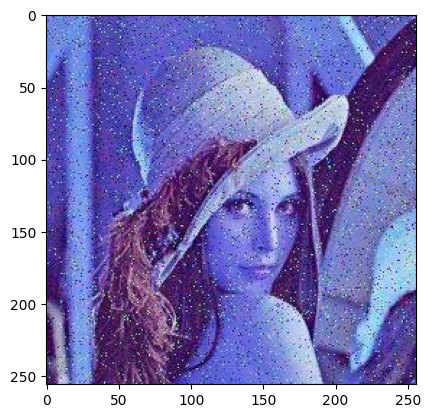

In [2]:
image = cv2.imread('../data/lenanoise.png')
plt.imshow(image)
r, g, b = image[:,:,0], image[:,:,1], image[:,:,2]
h, w, c = image.shape

In [3]:
image1 = np.zeros((h, w, c), dtype=image.dtype)
image1 [:,:,0] = b
image1 [:,:,1] = g
image1 [:,:,2] = r

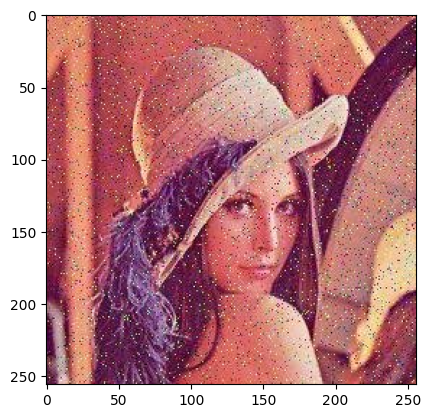

In [4]:
plt.imshow(image1)

In [5]:
dada = [5, 10, 0, 20, 19, 18, 45, 99, 11, 11, 15]
def bubble_sort(arr):
    n = len(arr)
    for i in range(n - 1):
        for j in range(n - 1 - i):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr
bubble_sort(dada.copy())


[0, 5, 10, 11, 11, 15, 18, 19, 20, 45, 99]

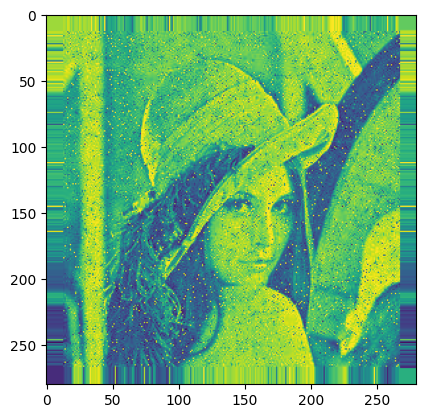

In [6]:
#создание массива с увеличенными границами для лучшей свертки
def reflect_borders(image, n): #image - изображение (не RGB либо отдельный канал), n - размерность ядра свертки
    h, w = image.shape
    conv_image = np.zeros((h+n//2+n//2, w+n//2+n//2),dtype=image.dtype)
    for j in range(h):
        for k in range(w):
            conv_image[j+n//2][k+n//2] = image[j][k]
    for j in range (n//2):
        for k in range(w+n//2+n//2):
            if (k < n//2):
                conv_image[j][k] = image[0][0]
            elif (k-n//2 >= w):
                conv_image[j][k] = image[0][w-1]
            elif (k < w+n//2):
                conv_image[j][k] = image[0][k-n//2]
    for j in range (h+n//2, h+n//2+n//2):
        for k in range(w+n//2+n//2):
            if (k < n//2):
                conv_image[j][k] = image[h-1][0]
            elif (k-n//2 >= w):
                conv_image[j][k] = image[h-1][w-1]
            elif (k < w+n//2):
                conv_image[j][k] = image[h-1][k-n//2]
    for j in range (n//2):
        for k in range(n//2 ,h+n//2):
            if (k-n//2 >= h):
                conv_image[k][j] = image[h-1][w-1]
            elif (k < h+n//2):
                conv_image[k][j] = image[k-n//2][0]
    for j in range (w+n//2, w+n//2+n//2):
        for k in range(n//2 ,h+n//2):
            if (k-n//2 >= h):
                conv_image[k][j] = image[h-1][w-1]
            elif (k < h+n//2):
                conv_image[k][j] = image[k-n//2][0]
    return conv_image
n = 25
tempimg = reflect_borders(image[:,:,2], n)
plt.imshow(tempimg)

In [7]:
#Медианный фильтр
n = 3 #размерность окна фильтра
image2 = np.zeros((h,w,c),dtype=image.dtype)
def median_filter(image, n): #image - изображение в RGB, n - размерность ядра свертки
    h, w, c = image.shape
    fltr_image = np.zeros((h,w,c),dtype=image.dtype)
    for i in range(c):
        tempimg = reflect_borders(image[:,:,i], n)
        for j in range(h):
            for k in range(w):
                core = np.zeros((n*n), dtype=image.dtype)
                p = 0
                for l1 in range(0, n):
                    for l2 in range(0, n):
                        core[p] = tempimg[j+l1][k+l2].copy() 
                        p = p + 1
                bubble_sort(core)
                u = p//2
                fltr_image[j][k][i] = core[u]
    return fltr_image

In [8]:
image2 = median_filter(image1.copy(), n)

In [9]:
image3 = cv2.medianBlur(image1.copy(), n)

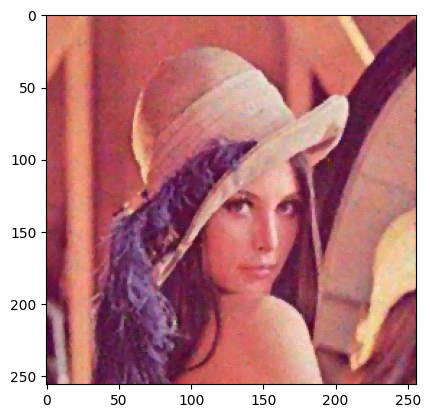

In [10]:
plt.imshow(image2)

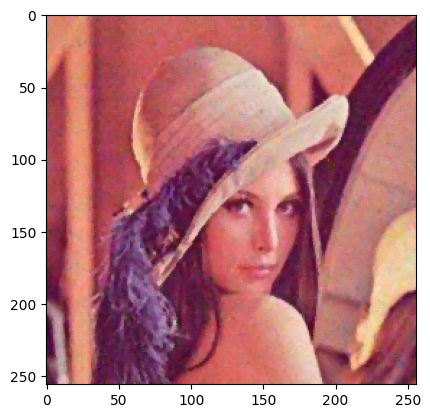

In [11]:
plt.imshow(image3)

In [12]:
#Фильтр Гаусса
def gaussian(m,n,sigma): #заполнение ядра Гаусса
    gaussian_kernel = np.zeros((m,n))
    for x in range(-m//2,m//2+1):
        for y in range(-n//2,n//2+1):
            gaussian_kernel[x+m//2][y+n//2] = np.exp(-(x**2+y**2)/(2*sigma**2))*(1/(2*np.pi*(sigma**2)))
    return gaussian_kernel

def normal_gaus(gaus):
    m = len(gaus)
    n = len(gaus[0])
    sum = 0
    for i in range (m):
        for j in range (n):
            sum += gaus[i][j]
    return gaus/sum
def gaussian_filter(m,n,sigma,image):
    gaus = gaussian(m,n,sigma)
    gaus = normal_gaus(gaus.copy())
    h, w, c = image.shape
    fltr_image = np.zeros((h,w,c),dtype=image.dtype)
    for i in range(c):
        tempimg = reflect_borders(image[:,:,i], n)
        for j in range(h):
            for k in range(w):
                out_pixel = 0
                core = np.zeros((m,n), dtype=image.dtype)
                for l1 in range(0, m):
                    for l2 in range(0, n):
                        core[l1][l2]=tempimg[j+l1][k+l2].copy()
                core = core * gaus
                for l1 in range(0, m):
                    for l2 in range(0, n):
                        out_pixel += core[l1][l2]
                fltr_image[j][k][i] = out_pixel
    return fltr_image

In [13]:
image4 = gaussian_filter(3,3,5,image1.copy())

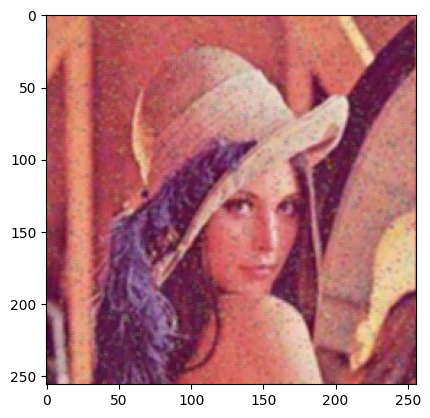

In [14]:
plt.imshow(image4)

In [22]:
def erosion(kernel, image):
    h, w, c = image.shape
    m = len(kernel)
    n = len(kernel[0])
    ersn_image = np.zeros((h,w,c),dtype=image.dtype)
    for i in range(c):
        tempimg = reflect_borders(image[:,:,i], n)
        for j in range(h):
            for k in range(w):
                min = 255
                core = np.zeros((m,n), dtype=image.dtype)
                for l1 in range(0, m):
                    for l2 in range(0, n):
                        core[l1][l2]=tempimg[j+l1][k+l2].copy()
                for l1 in range(0, m):
                    for l2 in range(0, n):
                        if(core[l1][l2] < min and kernel[l1][l2] != 0):
                            min = core[l1][l2].copy()
                ersn_image[j][k][i] = min
    return ersn_image
def dilatation(kernel, image):
    h, w, c = image.shape
    m = len(kernel)
    n = len(kernel[0])
    dilatated_image = np.zeros((h,w,c),dtype=image.dtype)
    for i in range(c):
        tempimg = reflect_borders(image[:,:,i], n)
        for j in range(h):
            for k in range(w):
                max = 0
                core = np.zeros((m,n), dtype=image.dtype)
                for l1 in range(0, m):
                    for l2 in range(0, n):
                        core[l1][l2]=tempimg[j+l1][k+l2].copy()
                for l1 in range(0, m):
                    for l2 in range(0, n):
                        if(core[l1][l2] > max and kernel[l1][l2] != 0):
                            max = core[l1][l2].copy()
                dilatated_image[j][k][i] = max
    return dilatated_image 

In [23]:
erosion_core = [
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
]
image5 = erosion(erosion_core,image1.copy())
image6 = dilatation(erosion_core, image1.copy())

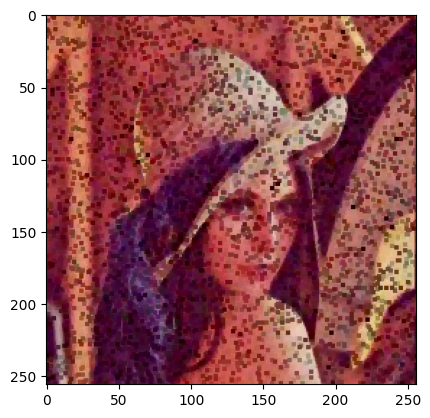

In [24]:
plt.imshow(image5)

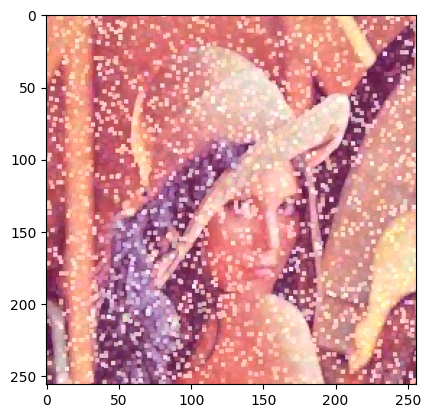

In [25]:
plt.imshow(image6)

In [29]:
kernel = np.ones((3,3), np.uint8)
eroded = cv2.erode(image1, kernel, iterations=1)
dilated = cv2.dilate(image1, kernel, iterations=1)

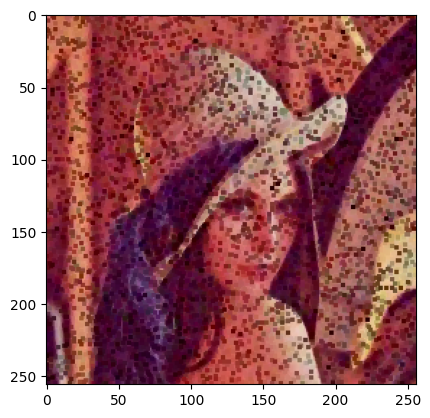

In [32]:
plt.imshow(eroded)


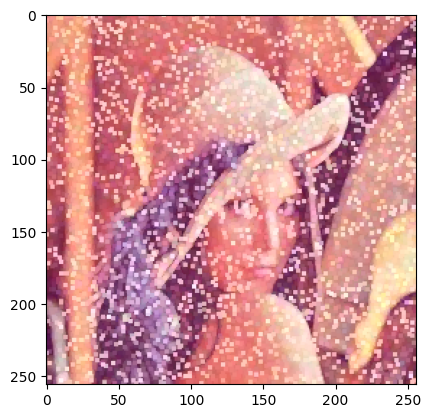

In [31]:
plt.imshow(dilated)